# Chapter 12, Question 9 — Hierarchical Clustering on USArrests

**Book:** An Introduction to Statistical Learning (ISLP), Chapter 12


## Load Data

In [1]:
# fetch the USArrests data the same way the book's lab does
from statsmodels.datasets import get_rdataset
USArrests = get_rdataset('USArrests').data


In [2]:
# preview the data: 50 states, 4 crime/urbanization variables
USArrests.head()


,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


## (a) Hierarchical Clustering — Complete Linkage, Euclidean Distance (Unscaled)

In [3]:
# fit hierarchical clustering with complete linkage on the raw (unscaled) data
from sklearn.cluster import AgglomerativeClustering
hc_raw = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='complete')
hc_raw.fit(USArrests)


,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",None
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'complete'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",0
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [4]:
# compute the linkage matrix needed to plot a dendrogram
from ISLP.cluster import compute_linkage
linkage_raw = compute_linkage(hc_raw)


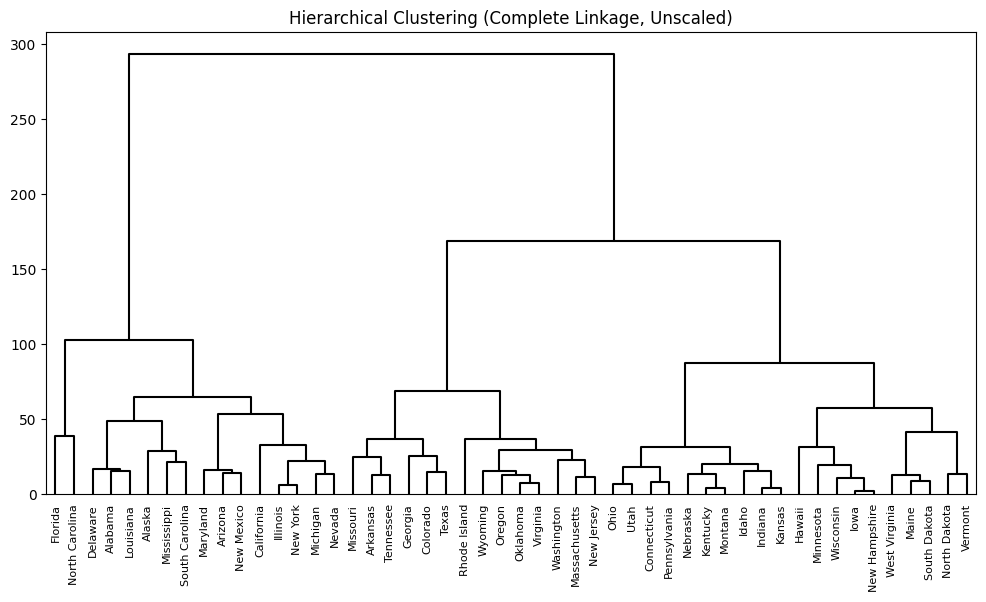

In [5]:
# plot the dendrogram for the unscaled data
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linkage_raw, labels=USArrests.index.to_list(), leaf_font_size=8, ax=ax,
           color_threshold=-1, above_threshold_color='black')
ax.set_title('Hierarchical Clustering (Complete Linkage, Unscaled)')
plt.show()


## (b) Cut the Dendrogram into 3 Clusters

In [6]:
# cut the unscaled dendrogram to obtain 3 clusters
from scipy.cluster.hierarchy import cut_tree
clusters_raw = cut_tree(linkage_raw, n_clusters=3).reshape(-1)


In [7]:
# list which states fall into each of the 3 clusters
import pandas as pd
pd.Series(clusters_raw, index=USArrests.index, name='cluster').sort_values()


rownames
Alabama           0
Alaska            0
Arizona           0
California        0
Delaware          0
Florida           0
Illinois          0
Louisiana         0
Michigan          0
Nevada            0
New Mexico        0
New York          0
Maryland          0
Mississippi       0
South Carolina    0
North Carolina    0
New Jersey        1
Missouri          1
Colorado          1
Massachusetts     1
Oklahoma          1
Oregon            1
Wyoming           1
Virginia          1
Tennessee         1
Texas             1
Washington        1
Rhode Island      1
Georgia           1
Arkansas          1
Hawaii            2
Connecticut       2
New Hampshire     2
Nebraska          2
Montana           2
Minnesota         2
Maine             2
Kentucky          2
Iowa              2
Kansas            2
Idaho             2
Indiana           2
North Dakota      2
Pennsylvania      2
Utah              2
South Dakota      2
Vermont           2
Ohio              2
West Virginia     2
Wisconsin  

In [8]:
# count how many states landed in each cluster
pd.Series(clusters_raw).value_counts().sort_index()


0    16
1    14
2    20
Name: count, dtype: int64

## (c) Hierarchical Clustering After Scaling Variables

In [9]:
# scale each variable to standard deviation one before clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
USArrests_scaled = scaler.fit_transform(USArrests)


In [10]:
# fit hierarchical clustering with complete linkage on the scaled data
hc_scaled = AgglomerativeClustering(distance_threshold=0, n_clusters=None, linkage='complete')
hc_scaled.fit(USArrests_scaled)
linkage_scaled = compute_linkage(hc_scaled)


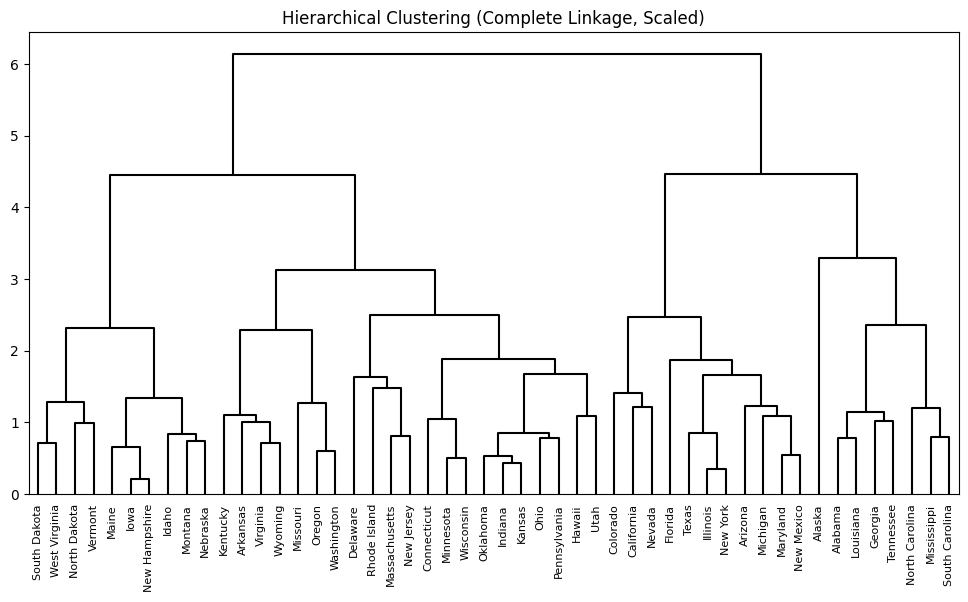

In [11]:
# plot the dendrogram for the scaled data
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linkage_scaled, labels=USArrests.index.to_list(), leaf_font_size=8, ax=ax,
           color_threshold=-1, above_threshold_color='black')
ax.set_title('Hierarchical Clustering (Complete Linkage, Scaled)')
plt.show()


In [12]:
# cut the scaled dendrogram to obtain 3 clusters and list the states in each
clusters_scaled = cut_tree(linkage_scaled, n_clusters=3).reshape(-1)
pd.Series(clusters_scaled, index=USArrests.index, name='cluster').sort_values()


rownames
Alabama           0
Alaska            0
Georgia           0
Louisiana         0
Mississippi       0
Tennessee         0
South Carolina    0
North Carolina    0
Maryland          1
Nevada            1
New Mexico        1
New York          1
Florida           1
Illinois          1
Colorado          1
Arizona           1
Texas             1
Michigan          1
California        1
Idaho             2
Kansas            2
Iowa              2
Indiana           2
Maine             2
Minnesota         2
Massachusetts     2
Kentucky          2
Missouri          2
Hawaii            2
Arkansas          2
Connecticut       2
Delaware          2
New Hampshire     2
New Jersey        2
Montana           2
Nebraska          2
Oklahoma          2
Oregon            2
Ohio              2
North Dakota      2
Rhode Island      2
Pennsylvania      2
South Dakota      2
Utah              2
Vermont           2
Virginia          2
Washington        2
West Virginia     2
Wisconsin         2
Wyoming    

## (d) Effect of Scaling — Comparison

We compare the unscaled vs. scaled 3-cluster assignments directly using a
crosstab: if scaling had no effect, each unscaled cluster would map cleanly
to exactly one scaled cluster.

In [13]:
# cross-tabulate unscaled vs scaled cluster assignments to see how much they differ
pd.crosstab(pd.Series(clusters_raw, name='Unscaled'), pd.Series(clusters_scaled, name='Scaled'))


Scaled,0,1,2
Unscaled,,,
0,6,9,1
1,2,2,10
2,0,0,20


In [14]:
# recall the variances of the original variables, to explain WHY scaling matters here
USArrests.var()


Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64